Comparación de modelos de clasificación: Árbol de Decisión vs. SVM

Objetivo

En este trabajo de la clase 6 se comparan dos modelos de clasificación supervisada: Árbol de Decisión y Support Vector Machine (SVM) lineal.

El objetivo es resolver un problema de clasificación utilizando el dataset Banknote Authentication que cuenta con Cantidad de registros: 1.372 filas, cuya fuente es: UCI Machine Learning Repository, un repositorio académico de datasets de la Universidad de California, Irvine.
 La misma contiene características numéricas extraídas de imágenes de billetes y permite clasificar los registros en dos clases.

A partir del entrenamiento y evaluación de ambos modelos, se analizará cuál presenta un mejor desempeño para abordar el problema.

In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
# Cargar el dataset Banknote Authentication desde UCI
banknote = fetch_ucirepo(id=267)

# Variables predictoras
X = banknote.data.features

# Variable objetivo
y = banknote.data.targets.squeeze()

# Crear un dataframe completo para observar los datos
df = X.copy()
df["class"] = y

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
df.shape

(1372, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [6]:
df.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [7]:
df["class"].value_counts()

,count
class,
0,762
1,610


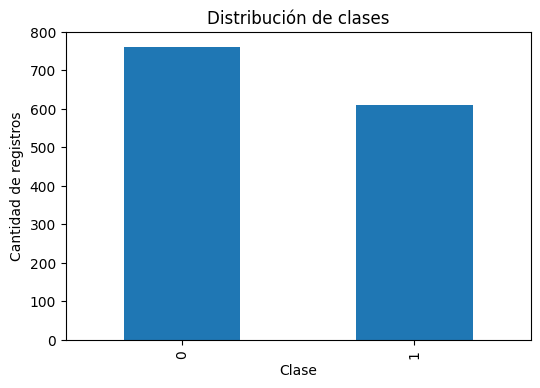

In [8]:
plt.figure(figsize=(6,4))
df["class"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")

plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (1097, 4)
Tamaño del conjunto de prueba: (275, 4)


**Árbol de Decisión**

In [10]:
modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

In [11]:
accuracy_arbol = accuracy_score(y_test, pred_arbol)
precision_arbol = precision_score(y_test, pred_arbol, average="weighted")
recall_arbol = recall_score(y_test, pred_arbol, average="weighted")
f1_arbol = f1_score(y_test, pred_arbol, average="weighted")

print("Accuracy:", accuracy_arbol)
print("Precision:", precision_arbol)
print("Recall:", recall_arbol)
print("F1-score:", f1_arbol)

print("\nReporte de clasificación:")
print(classification_report(y_test, pred_arbol))

Accuracy: 0.9927272727272727
Precision: 0.9928445747800585
Recall: 0.9927272727272727
F1-score: 0.9927329132142995

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



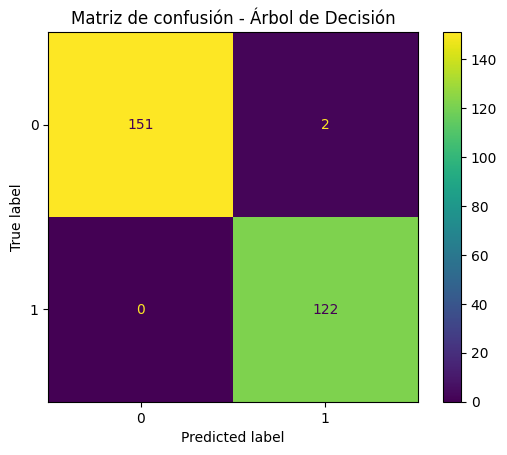

In [12]:
matriz_arbol = confusion_matrix(y_test, pred_arbol)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_arbol)
disp.plot()

plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

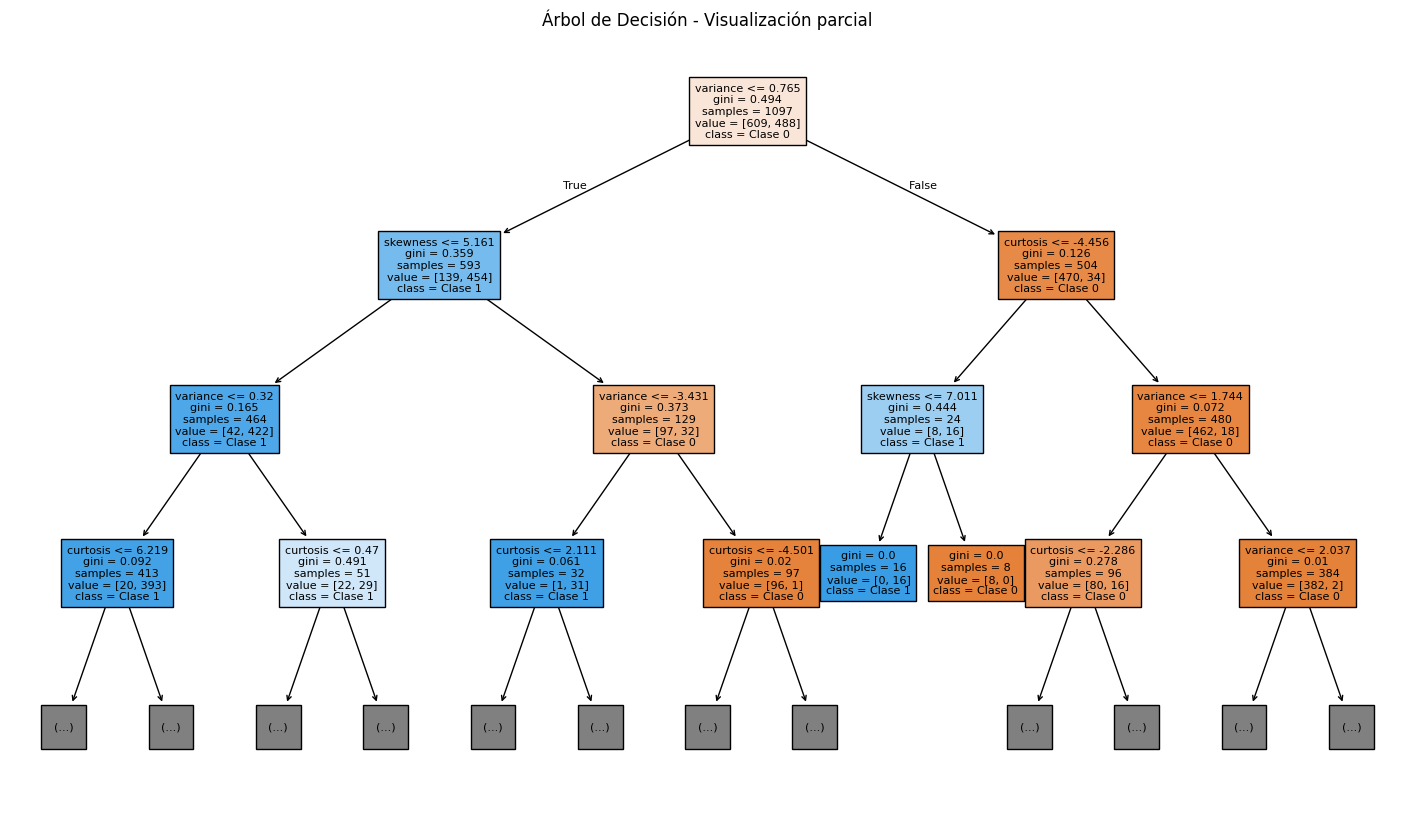

In [13]:
plt.figure(figsize=(18,10))

plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=["Clase 0", "Clase 1"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Árbol de Decisión - Visualización parcial")
plt.show()

**SVM lineal**

In [14]:
modelo_svm = Pipeline([
    ("escalado", StandardScaler()),
    ("clasificador", SVC(kernel="linear"))
])

modelo_svm.fit(X_train, y_train)

pred_svm = modelo_svm.predict(X_test)

In [15]:
accuracy_svm = accuracy_score(y_test, pred_svm)
precision_svm = precision_score(y_test, pred_svm, average="weighted")
recall_svm = recall_score(y_test, pred_svm, average="weighted")
f1_svm = f1_score(y_test, pred_svm, average="weighted")

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

print("\nReporte de clasificación:")
print(classification_report(y_test, pred_svm))

Accuracy: 0.9745454545454545
Precision: 0.9759267089499649
Recall: 0.9745454545454545
F1-score: 0.974602435499716

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       153
           1       0.95      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.98      0.97       275
weighted avg       0.98      0.97      0.97       275



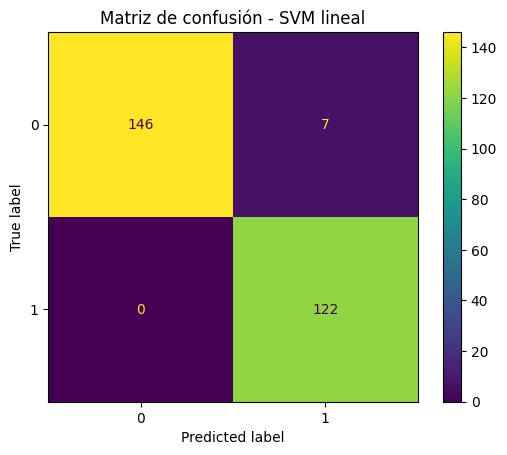

In [16]:
matriz_svm = confusion_matrix(y_test, pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_svm)
disp.plot()

plt.title("Matriz de confusión - SVM lineal")
plt.show()

**Comparación**

In [17]:
resultados = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "SVM lineal"],
    "Accuracy": [accuracy_arbol, accuracy_svm],
    "Precision": [precision_arbol, precision_svm],
    "Recall": [recall_arbol, recall_svm],
    "F1-score": [f1_arbol, f1_svm]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Árbol de Decisión,0.992727,0.992845,0.992727,0.992733
1,SVM lineal,0.974545,0.975927,0.974545,0.974602


**Gráfico comparativo**

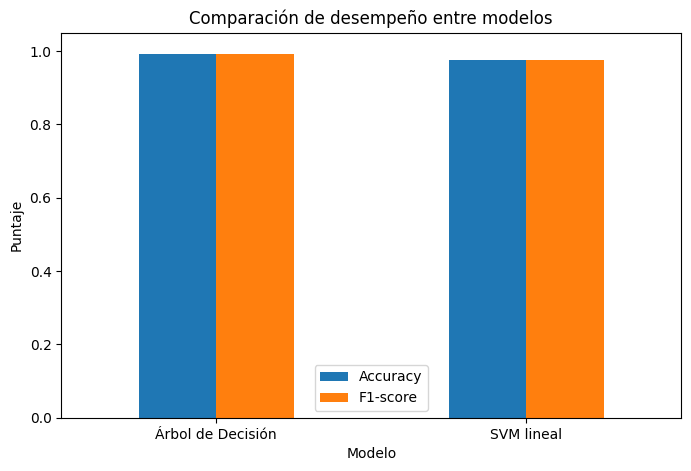

In [18]:
resultados.set_index("Modelo")[["Accuracy", "F1-score"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparación de desempeño entre modelos")
plt.ylabel("Puntaje")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

In [19]:
mejor_modelo = resultados.sort_values("F1-score", ascending=False).iloc[0]

print("El modelo con mejor F1-score fue:", mejor_modelo["Modelo"])
print("F1-score:", mejor_modelo["F1-score"])

El modelo con mejor F1-score fue: Árbol de Decisión
F1-score: 0.9927329132142995


Conclusión

En este trabajo se compararon dos modelos de clasificación supervisada: Árbol de Decisión y SVM lineal, aplicados al dataset Banknote Authentication.

Ambos modelos lograron un desempeño alto en la clasificación de los registros. Sin embargo, el Árbol de Decisión obtuvo mejores resultados en todas las métricas evaluadas. Alcanzó un accuracy de 0.9927 y un F1-score de 0.9927, mientras que la SVM lineal obtuvo un accuracy de 0.9745 y un F1-score de 0.9746.

Esto indica que, para este conjunto de datos, el Árbol de decisión logró clasificar correctamente una mayor cantidad de casos y mostró un rendimiento general más alto.

Por este motivo, a partir de los resultados obtenidos el Árbol de Decisión aborda mejor este problema de aprendizaje automático, aunque la SVM lineal también presentó resultados  satisfactorios.